In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
data_tvbs公路 = pd.read_csv('tvbs_蘇花公路_full.csv').drop(columns='Link').dropna().reset_index(drop=True) #1177
data_tvbs高 = pd.read_csv('tvbs_蘇花高_full.csv').drop(columns='Link').dropna().reset_index(drop=True) #118
data_tvbs改 = pd.read_csv('tvbs_蘇花改_full.csv').drop(columns='Link').dropna().reset_index(drop=True) #380
data_中時公路 = pd.read_csv('中時_蘇花公路_full.csv').drop(columns='Link').dropna().reset_index(drop=True) #3959

data = pd.concat([data_tvbs公路, data_tvbs高, data_tvbs改, data_中時公路], ignore_index=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Title        5634 non-null   object
 1   Context      5634 non-null   object
 2   PublishTime  5634 non-null   object
dtypes: object(3)
memory usage: 132.2+ KB


In [8]:
data['Context'].duplicated().sum()

135

In [9]:
data = data[~data['Context'].duplicated()].reset_index(drop=True)

In [10]:
data.head(10)

,Title,Context,PublishTime
0,地震、豪雨夾擊！中橫落石阻斷明搶通 蘇花公路夜間恐預警封閉,受到昨（11）日東部規模6.4地震及熱帶低壓降雨影響，中橫公路台8線157.7k豁然亭路段，...,2025/06/12 15:50
1,花蓮暴雨頻傳災情！7學生砂婆噹溪「戲水受困」,花蓮地區下午到晚上期間，大雨與雷聲不間斷，有7名學生到知名景點砂婆噹戲水，返程時，遇到溪水暴...,2025/06/08 20:53
2,豪雨重創花蓮！徐榛蔚喊話賴清德「不要搭專機」 體驗交通之苦,近日豪雨影響，花蓮北上鐵公路再度中斷，導致交通受阻，縣長徐榛蔚今天攜手多位議員及觀光產業界，...,2025/05/21 13:10
3,3天2中斷！台鐵單線雙向 花端午訂房剩3.5成,台鐵北迴線，受到大雨影響，兩度雙向中斷無法通行，昨天連蘇花公路都受影響，台鐵宣布在今天清晨4...,2025/05/21 12:49
4,鐵路公路雙癱瘓！台鐵和仁段又豪雨停駛 蘇花崇德段只出不進,花蓮縣18日下午受到對流雲系發展旺盛影響，下起傾盆大雨，導致台鐵「和仁=崇德」遭土石流淹沒軌...,2025/05/20 17:11
5,駕駛注意！蘇花中仁隧道南下線施工 5／13起「封閉17天」,用路人注意！為進行排水改善並復原路面施工，台9線蘇花改「中仁隧道南下線」自今（13）日上午起...,2025/05/13 11:56
6,清明連假首日爆出遊潮！蘇花恐塞14小時 桃機估湧14.5萬人,清明4天連假即將到來，交通部公路局預估本次連假車潮將以掃墓祭祖及觀光旅遊為主，省道主要幹道及...,2025/04/01 09:45
7,騎士檢舉違規遭退件 控警消極未通知補件,上個月初，有機車騎士在蘇花公路，差點被對向一輛跨越雙黃線的休旅車撞上，騎士隔天上網檢舉，不過...,2025/01/03 18:36
8,赴花蓮玩出事了！小客車舊蘇花公路起火 姐弟倆急跳車逃命,今（2）日中午12時許，宜蘭縣南澳鄉台九丁線46.9公里處南下，發生火燒車意外，車上49歲趙...,2024/12/02 14:30
9,蘇花搶通！上萬立方公尺土石掩埋 7怪手搶修,康芮颱風侵襲帶來許多災情，在蘇花公路匯德隧道北口，發生土石流，高達1萬2千立方公尺的土石掩埋...,2024/11/02 17:46


In [12]:
data['PublishTime'] = pd.to_datetime(data['PublishTime'], format='%Y/%m/%d %H:%M', errors='coerce')

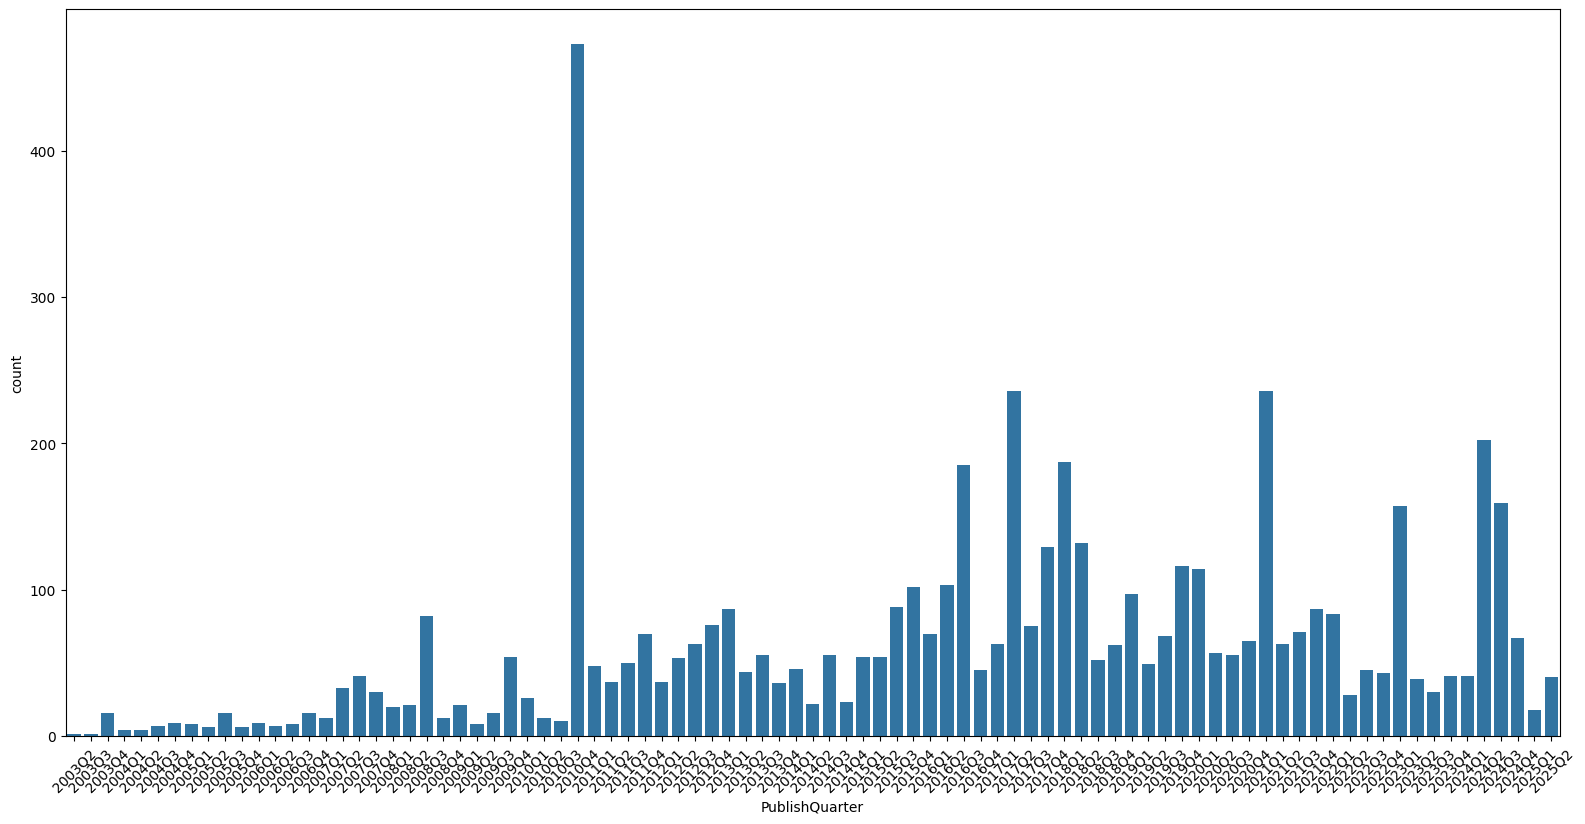

In [13]:
data['PublishQuarter'] = data['PublishTime'].dt.to_period('Q').astype(str)
plt.figure(figsize=(16, 8))
sns.countplot(data=data, x='PublishQuarter', order=sorted(data['PublishQuarter']))
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

In [14]:
text_all = '\n'.join(data['Context'].dropna())

In [15]:
import jieba, re, string

In [16]:
fullwidth_punctuation = "，。！？：；「」『』（）〔〕【】《》—…～‧、．"
all_punct = string.punctuation + fullwidth_punctuation
def clean_text(text):
    if pd.isna(text):
        return ''
    text = text.lower()
    text = text.translate(str.maketrans('', '', all_punct))  # 刪標點
    text = re.sub(r'\[.*?\]', '', text)                               # 刪 [] 內內容
    text = re.sub(r'https?://\S+|www\.\S+', '', text)                 # 刪網址
    text = re.sub(r'<.*?>+', '', text)                                # 刪 HTML tag
    text = re.sub(r'\n', ' ', text)                                   # 換行→空白
    # text = re.sub(r'\w*\d\w*', ' ', text)                             # 含數字詞
    text = re.sub(r'\d+', ' ', text)                                  # 數字
    text = re.sub(r'\s+', ' ', text).strip()                          # 連續空白
    return text
data["Cleaned_Context"] = data["Context"].apply(clean_text)
data.head(10)

,Title,Context,PublishTime,PublishQuarter,Cleaned_Context
0,地震、豪雨夾擊！中橫落石阻斷明搶通 蘇花公路夜間恐預警封閉,受到昨（11）日東部規模6.4地震及熱帶低壓降雨影響，中橫公路台8線157.7k豁然亭路段，...,2025-06-12 15:50:00,2025Q2,受到昨 日東部規模 地震及熱帶低壓降雨影響中橫公路台 線 k豁然亭路段今 日下午 時許上邊坡...
1,花蓮暴雨頻傳災情！7學生砂婆噹溪「戲水受困」,花蓮地區下午到晚上期間，大雨與雷聲不間斷，有7名學生到知名景點砂婆噹戲水，返程時，遇到溪水暴...,2025-06-08 20:53:00,2025Q2,花蓮地區下午到晚上期間大雨與雷聲不間斷有 名學生到知名景點砂婆噹戲水返程時遇到溪水暴漲受困等...
2,豪雨重創花蓮！徐榛蔚喊話賴清德「不要搭專機」 體驗交通之苦,近日豪雨影響，花蓮北上鐵公路再度中斷，導致交通受阻，縣長徐榛蔚今天攜手多位議員及觀光產業界，...,2025-05-21 13:10:00,2025Q2,近日豪雨影響花蓮北上鐵公路再度中斷導致交通受阻縣長徐榛蔚今天攜手多位議員及觀光產業界公開向總...
3,3天2中斷！台鐵單線雙向 花端午訂房剩3.5成,台鐵北迴線，受到大雨影響，兩度雙向中斷無法通行，昨天連蘇花公路都受影響，台鐵宣布在今天清晨4...,2025-05-21 12:49:00,2025Q2,台鐵北迴線受到大雨影響兩度雙向中斷無法通行昨天連蘇花公路都受影響台鐵宣布在今天清晨 點多總算...
4,鐵路公路雙癱瘓！台鐵和仁段又豪雨停駛 蘇花崇德段只出不進,花蓮縣18日下午受到對流雲系發展旺盛影響，下起傾盆大雨，導致台鐵「和仁=崇德」遭土石流淹沒軌...,2025-05-20 17:11:00,2025Q2,花蓮縣 日下午受到對流雲系發展旺盛影響下起傾盆大雨導致台鐵和仁崇德遭土石流淹沒軌道北迴線雙向...
5,駕駛注意！蘇花中仁隧道南下線施工 5／13起「封閉17天」,用路人注意！為進行排水改善並復原路面施工，台9線蘇花改「中仁隧道南下線」自今（13）日上午起...,2025-05-13 11:56:00,2025Q2,用路人注意為進行排水改善並復原路面施工台 線蘇花改中仁隧道南下線自今 日上午起到 月 日下午...
6,清明連假首日爆出遊潮！蘇花恐塞14小時 桃機估湧14.5萬人,清明4天連假即將到來，交通部公路局預估本次連假車潮將以掃墓祭祖及觀光旅遊為主，省道主要幹道及...,2025-04-01 09:45:00,2025Q2,清明 天連假即將到來交通部公路局預估本次連假車潮將以掃墓祭祖及觀光旅遊為主省道主要幹道及各地...
7,騎士檢舉違規遭退件 控警消極未通知補件,上個月初，有機車騎士在蘇花公路，差點被對向一輛跨越雙黃線的休旅車撞上，騎士隔天上網檢舉，不過...,2025-01-03 18:36:00,2025Q1,上個月初有機車騎士在蘇花公路差點被對向一輛跨越雙黃線的休旅車撞上騎士隔天上網檢舉不過卻被退件...
8,赴花蓮玩出事了！小客車舊蘇花公路起火 姐弟倆急跳車逃命,今（2）日中午12時許，宜蘭縣南澳鄉台九丁線46.9公里處南下，發生火燒車意外，車上49歲趙...,2024-12-02 14:30:00,2024Q4,今 日中午 時許宜蘭縣南澳鄉台九丁線 公里處南下發生火燒車意外車上 歲趙姓男駕駛與姊姊從桃園...
9,蘇花搶通！上萬立方公尺土石掩埋 7怪手搶修,康芮颱風侵襲帶來許多災情，在蘇花公路匯德隧道北口，發生土石流，高達1萬2千立方公尺的土石掩埋...,2024-11-02 17:46:00,2024Q4,康芮颱風侵襲帶來許多災情在蘇花公路匯德隧道北口發生土石流高達 萬 千立方公尺的土石掩埋道路公...


In [17]:
def tokenize(text):
    if pd.isna(text):
        return []
    return list(jieba.cut(text))

data['Tokens'] = data['Cleaned_Context'].apply(tokenize)

Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\USER\AppData\Local\Temp\jieba.cache
Loading model cost 0.224 seconds.
Prefix dict has been built succesfully.


In [18]:
data

,Title,Context,PublishTime,PublishQuarter,Cleaned_Context,Tokens
0,地震、豪雨夾擊！中橫落石阻斷明搶通 蘇花公路夜間恐預警封閉,受到昨（11）日東部規模6.4地震及熱帶低壓降雨影響，中橫公路台8線157.7k豁然亭路段，...,2025-06-12 15:50:00,2025Q2,受到昨 日東部規模 地震及熱帶低壓降雨影響中橫公路台 線 k豁然亭路段今 日下午 時許上邊坡...,"[受到, 昨, , 日, 東部, 規模, , 地震, 及, 熱帶, 低壓, 降雨, 影響..."
1,花蓮暴雨頻傳災情！7學生砂婆噹溪「戲水受困」,花蓮地區下午到晚上期間，大雨與雷聲不間斷，有7名學生到知名景點砂婆噹戲水，返程時，遇到溪水暴...,2025-06-08 20:53:00,2025Q2,花蓮地區下午到晚上期間大雨與雷聲不間斷有 名學生到知名景點砂婆噹戲水返程時遇到溪水暴漲受困等...,"[花蓮, 地區, 下午, 到, 晚上, 期間, 大雨, 與, 雷聲, 不, 間斷, 有, ..."
2,豪雨重創花蓮！徐榛蔚喊話賴清德「不要搭專機」 體驗交通之苦,近日豪雨影響，花蓮北上鐵公路再度中斷，導致交通受阻，縣長徐榛蔚今天攜手多位議員及觀光產業界，...,2025-05-21 13:10:00,2025Q2,近日豪雨影響花蓮北上鐵公路再度中斷導致交通受阻縣長徐榛蔚今天攜手多位議員及觀光產業界公開向總...,"[近日, 豪雨, 影響, 花蓮, 北上, 鐵公路, 再度, 中斷, 導致, 交通, 受阻, ..."
3,3天2中斷！台鐵單線雙向 花端午訂房剩3.5成,台鐵北迴線，受到大雨影響，兩度雙向中斷無法通行，昨天連蘇花公路都受影響，台鐵宣布在今天清晨4...,2025-05-21 12:49:00,2025Q2,台鐵北迴線受到大雨影響兩度雙向中斷無法通行昨天連蘇花公路都受影響台鐵宣布在今天清晨 點多總算...,"[台鐵, 北迴線, 受到, 大雨, 影響, 兩, 度, 雙向, 中斷, 無法, 通行, 昨天..."
4,鐵路公路雙癱瘓！台鐵和仁段又豪雨停駛 蘇花崇德段只出不進,花蓮縣18日下午受到對流雲系發展旺盛影響，下起傾盆大雨，導致台鐵「和仁=崇德」遭土石流淹沒軌...,2025-05-20 17:11:00,2025Q2,花蓮縣 日下午受到對流雲系發展旺盛影響下起傾盆大雨導致台鐵和仁崇德遭土石流淹沒軌道北迴線雙向...,"[花蓮縣, , 日, 下午, 受到, 對流雲系, 發展, 旺盛, 影響, 下起, 傾盆大雨..."
...,...,...,...,...,...,...
5494,交通 初二比初一好多了,〔記者李文儀、吳正庭、游明金、曾鴻儒、丁偉杰、楊菁菁╱綜合報導〕昨天是傳統回娘家的日子，高速...,2005-02-11 06:00:00,2005Q1,記者李文儀吳正庭游明金曾鴻儒丁偉杰楊菁菁╱綜合報導昨天是傳統回娘家的日子高速公路及各地主要道...,"[記者, 李文儀, 吳, 正, 庭游, 明金, 曾, 鴻儒, 丁偉杰, 楊, 菁菁, ╱, ..."
5495,花蓮對外公路 條條暢通,〔記者楊宜中╱花蓮報導〕有別於往年在除夕一定出現爆滿的歸鄉人潮，花蓮昨天對外航空交通、公路交...,2005-02-09 06:00:00,2005Q1,記者楊宜中╱花蓮報導有別於往年在除夕一定出現爆滿的歸鄉人潮花蓮昨天對外航空交通公路交通及鐵路...,"[記者, 楊, 宜中, ╱, 花蓮, 報導, 有別於, 往年, 在, 除夕, 一定, 出現,..."
5496,開車返鄉 轉個彎路更寬,〔記者李文儀╱台北報導〕農曆春節假期今天正式展開，昨天鐵路、公路客運及松山機場的旅客略微增加...,2005-02-06 06:00:00,2005Q1,記者李文儀╱台北報導農曆春節假期今天正式展開昨天鐵路公路客運及松山機場的旅客略微增加但不像往...,"[記者, 李文儀, ╱, 台北, 報導, 農曆, 春節, 假期, 今天, 正式, 展開, 昨..."
5497,蘇花高 美軍援台要道,〔記者游太郎、李文儀╱綜合報導〕蘇花高速公路興建與否，一直引起東部民眾的高度關注，軍方最近針...,2004-12-25 06:00:00,2004Q4,記者游太郎李文儀╱綜合報導蘇花高速公路興建與否一直引起東部民眾的高度關注軍方最近針對歷次漢光...,"[記者, 游, 太郎, 李文儀, ╱, 綜合, 報導, 蘇花, 高速, 公路, 興建, 與否..."


In [19]:
with open('停用詞-繁體中文.txt', encoding='utf-8') as f:
    stopwords = set(line.strip() for line in f)

In [20]:
def tokenize_filtered(text):
    if pd.isna(text):
        return []
    tokens = jieba.cut(text)
    return [ t for t in tokens if t not in stopwords and len(t)>1 and t.isalpha()]

In [21]:
data['Tokens'] = data['Cleaned_Context'].apply(tokenize_filtered)

In [22]:
data[['Title', 'Tokens']].head(10)


,Title,Tokens
0,地震、豪雨夾擊！中橫落石阻斷明搶通 蘇花公路夜間恐預警封閉,"[受到, 東部, 規模, 地震, 熱帶, 低壓, 降雨, 影響, 中橫公路台, 路段, 下午..."
1,花蓮暴雨頻傳災情！7學生砂婆噹溪「戲水受困」,"[花蓮, 地區, 下午, 晚上, 期間, 大雨, 雷聲, 間斷, 學生, 知名, 景點, 砂..."
2,豪雨重創花蓮！徐榛蔚喊話賴清德「不要搭專機」 體驗交通之苦,"[近日, 豪雨, 影響, 花蓮, 北上, 鐵公路, 再度, 中斷, 導致, 交通, 受阻, ..."
3,3天2中斷！台鐵單線雙向 花端午訂房剩3.5成,"[台鐵, 北迴線, 受到, 大雨, 影響, 雙向, 中斷, 無法, 通行, 昨天, 蘇花公路..."
4,鐵路公路雙癱瘓！台鐵和仁段又豪雨停駛 蘇花崇德段只出不進,"[花蓮縣, 下午, 受到, 對流雲系, 發展, 旺盛, 影響, 下起, 傾盆大雨, 導致, ..."
5,駕駛注意！蘇花中仁隧道南下線施工 5／13起「封閉17天」,"[路人, 注意, 進行, 排水, 改善, 復原, 路面, 施工, 蘇花, 中仁, 隧道, 南..."
6,清明連假首日爆出遊潮！蘇花恐塞14小時 桃機估湧14.5萬人,"[清明, 連假, 到來, 交通部, 公路局, 預估, 連假, 車潮, 掃墓, 祭祖, 觀光,..."
7,騎士檢舉違規遭退件 控警消極未通知補件,"[月初, 機車, 騎士, 蘇花公路, 差點, 跨越, 雙黃線, 休旅車, 撞上, 騎士, 隔..."
8,赴花蓮玩出事了！小客車舊蘇花公路起火 姐弟倆急跳車逃命,"[中午, 時許, 宜蘭縣, 南澳鄉, 台九, 丁線, 公里, 南下, 發生, 火燒車, 意外..."
9,蘇花搶通！上萬立方公尺土石掩埋 7怪手搶修,"[康芮, 颱風, 侵襲, 帶來, 許多, 災情, 蘇花公路, 匯德, 隧道, 北口, 發生,..."


In [23]:
from collections import Counter
all_tokens = [token for tokens in data['Tokens'] for token in tokens]
word_freq = Counter(all_tokens)
top_tf = word_freq.most_common(30)

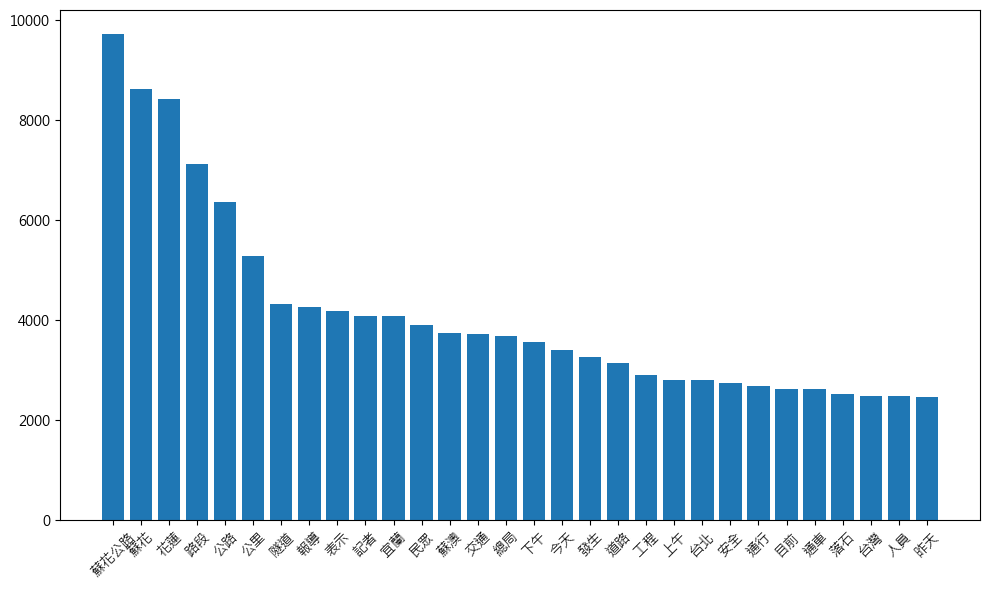

In [24]:
plt.rcParams['font.family'] = 'Microsoft JhengHei'  # or 'Noto Sans TC'
plt.rcParams['axes.unicode_minus'] = False
words, freqs = zip(*top_tf)
plt.figure(figsize=(10, 6))
plt.bar(words, freqs)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
data['Joined_Tokens'] = data['Tokens'].apply(lambda x: ' '.join(x))
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(data['Joined_Tokens'])
feature_names = tfidf.get_feature_names_out()
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names)


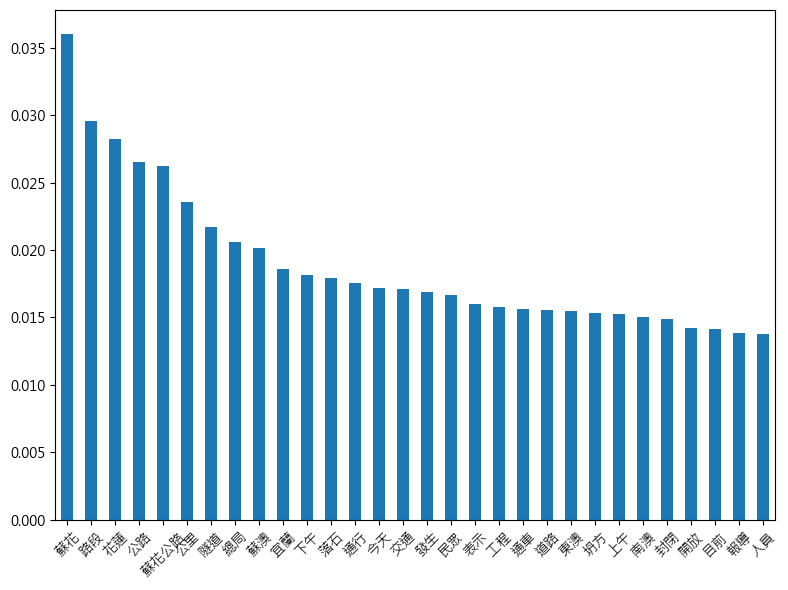

In [26]:
mead_tfidf = tfidf_df.mean().sort_values(ascending=False)
top_tfidf = mead_tfidf.head(30)
top_tfidf.plot(kind='bar', figsize=(8, 6))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [27]:
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer

In [55]:
vectorizer = CountVectorizer()
count_matrix = vectorizer.fit_transform(data['Joined_Tokens'])
lda = LatentDirichletAllocation(n_components=4, random_state=42)
lda_matrix = lda.fit_transform(count_matrix)

data['Topic'] = lda_matrix.argmax(axis=1)

In [56]:
def display_topics(model, feature_names, topn=20):
    for index, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-topn-1:-1]]
        print(f'主題 {index+1}: {'、'.join(top_words)}')
display_topics(lda, vectorizer.get_feature_names_out())

主題 1: 蘇花、花蓮、隧道、蘇花公路、公路、工程、通車、安全、交通、表示、改善、公里、路段、蘇澳、交通部、計畫、東澳、民眾、道路、記者
主題 2: 台灣、花蓮、台北、報導、活動、環島、美食、遊客、日本、旅遊、記者、宜蘭、飯店、蘇花公路、觀光、今年、單車、玩咖、體驗、完整
主題 3: 路段、蘇花公路、公路、下午、花蓮、總局、公里、上午、封閉、今天、通行、宜蘭、颱風、蘇花、交通、蘇澳、管制、道路、民眾、落石
主題 4: 蘇花公路、遊覽車、發生、人員、花蓮、駕駛、公里、警方、發現、宜蘭、記者、報導、家屬、司機、搜救、表示、現場、意外、地震、事故


C:\Users\USER\AppData\Local\Temp\ipykernel_26952\1723535593.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='Topic', palette='Set2')


<Axes: xlabel='Topic', ylabel='count'>

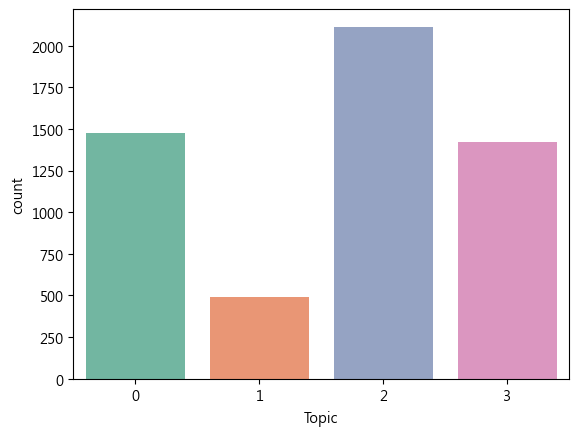

In [57]:
sns.countplot(data=data, x='Topic', palette='Set2')

In [58]:
from sklearn.manifold import TSNE

<Axes: xlabel='x', ylabel='y'>

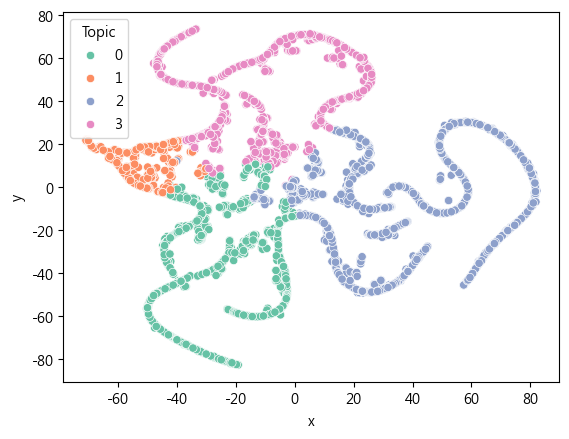

In [59]:
tsne = TSNE(n_components=2, random_state=42)
lda_tsne = tsne.fit_transform(lda_matrix)
tsne_df = pd.DataFrame(lda_tsne, columns=['x', 'y'])
tsne_df['Topic'] = data['Topic']

sns.scatterplot(data=tsne_df, x='x', y='y', hue='Topic', palette='Set2')

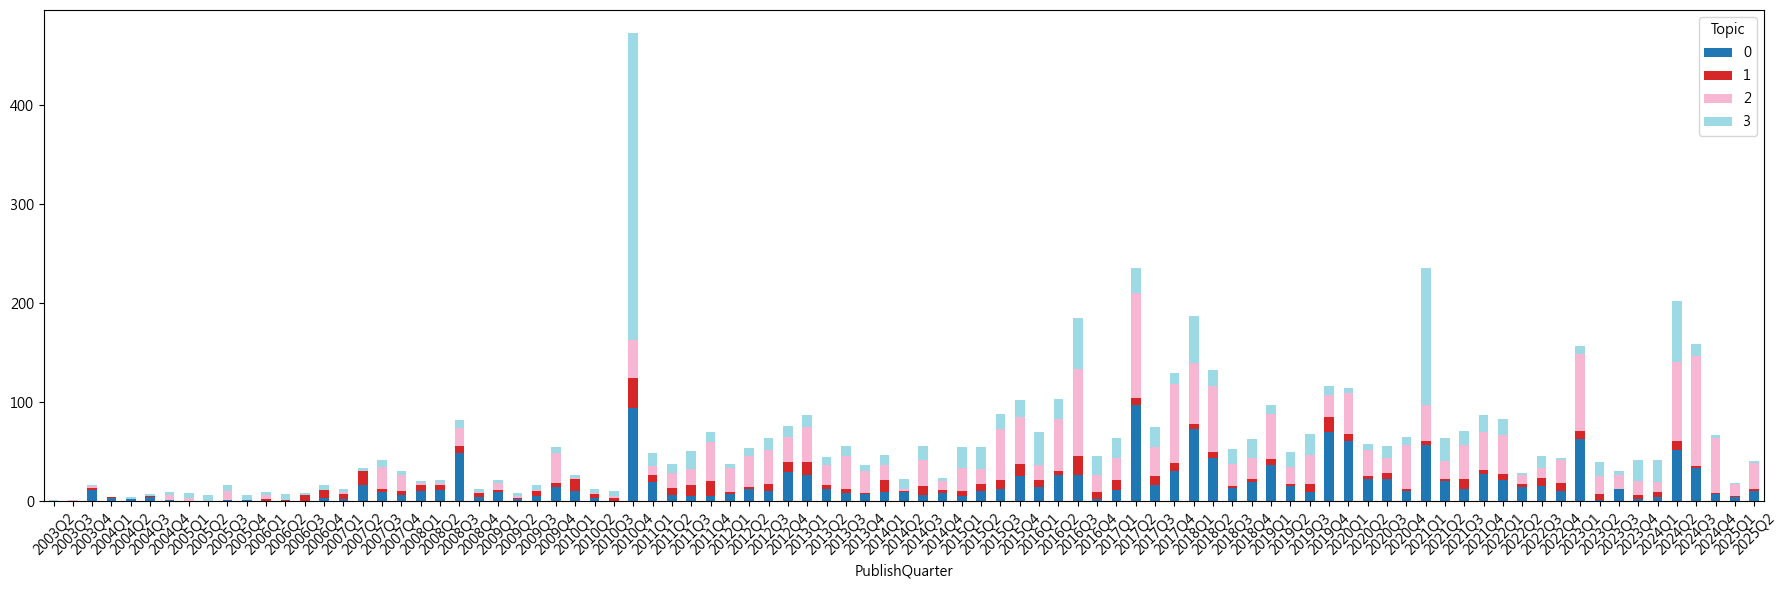

In [65]:
topic_quarter = data.groupby(['PublishQuarter', 'Topic']).size().unstack(fill_value=0)

topic_quarter.plot(kind='bar', stacked=True, colormap='tab20', figsize=(18, 6))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

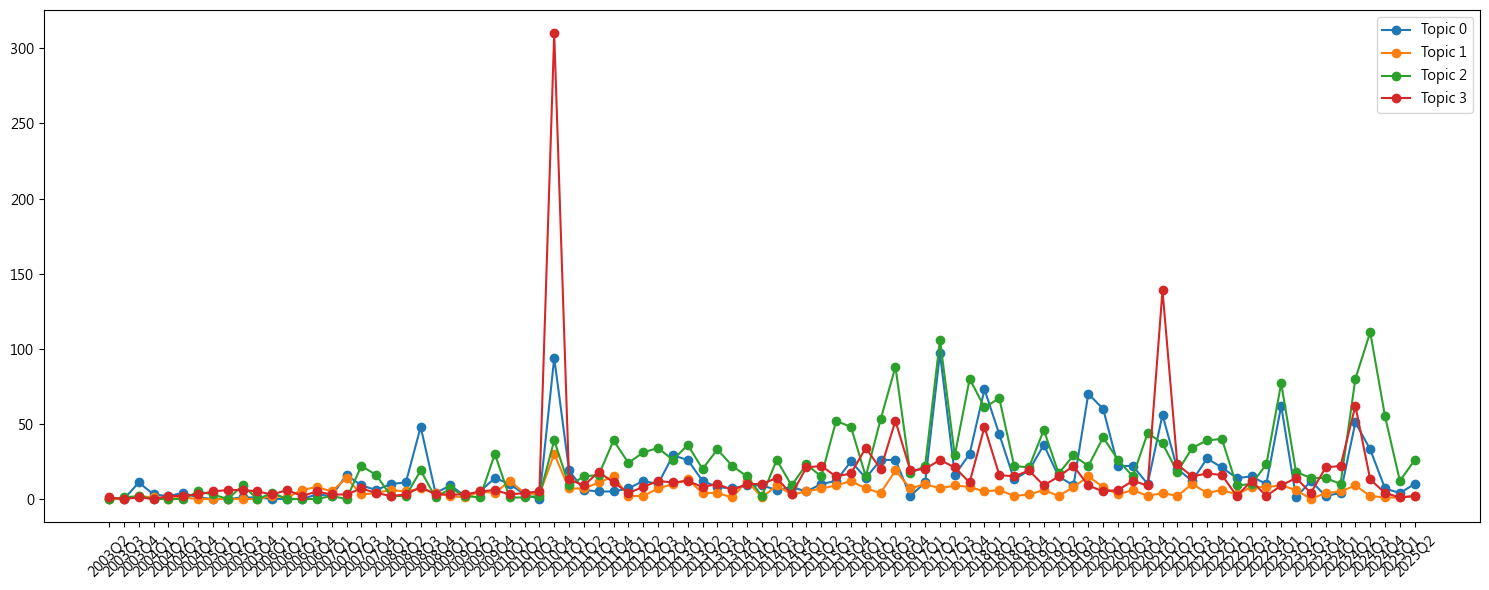

In [61]:
all_quarters = sorted(data['PublishQuarter'].unique())

plt.figure(figsize=(15, 6))
for topic in sorted(data['Topic'].unique()):
    topic_group = data[data['Topic'] == topic].groupby('PublishQuarter').size()
    topic_group = topic_group.reindex(all_quarters, fill_value=0)
    plt.plot(all_quarters, topic_group, marker='o', label=f'Topic {topic}')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [62]:
# 取得所有詞彙（對應每一欄）
terms = vectorizer.get_feature_names_out()

# 建立詞頻 DataFrame：每列為一篇文章
df_count = pd.DataFrame(count_matrix.toarray(), columns=terms)

df_count.head()


,aa,aapme,aav,ab,abc,abcd,able,about,above,abs,...,龜山鄉,龜庵,龜洞,龜縮,龜裂,龜記,龜車,龜速,龜首,龜鼻
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [63]:
n_topics = lda.n_components  # 主題數
topic_cols = [f'Topic {i}' for i in range(n_topics)]

df_lda = pd.DataFrame(lda_matrix, columns=topic_cols)

# 顯示前幾篇的主題機率
df_lda.head()


,Topic 0,Topic 1,Topic 2,Topic 3
0,0.001284,0.001263,0.996168,0.001285
1,0.001336,0.001365,0.566826,0.430473
2,0.807881,0.020189,0.170683,0.001247
3,0.413947,0.001157,0.583712,0.001183
4,0.001161,0.001114,0.996591,0.001133
